# All About Simulations

The {class}`~tambora.simulation.Sim` class is the core of {ref}`home`. It orchestrates building, running, and analyzing n-body simulations and is what you will interact with the most as a result. Instantiating a simulation is as simple as the following:

In [13]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [8]:
from tambora.simulation import Sim

sim = Sim()

## Adding a Set of Particles to Your Simulation

To add a collection of (optionally) self gravitating particles that (optionally) experience external forces to your simulation, use the {method}`~tambora.simulation.Sim.add_particles` method on your {class}`~tambora.simulation.Sim` instance.

You must name the collection of particles when you add them to the simulation. The name you provide is used to access individual components of simulations with multiple components (discussed in **Adding Multiple Sets of Particles**). The positions and velocities are expected to be (N, 3) arrays in cartesian coordinates and the masses an (N,) array. Positions are expected to be provided in units of kpc, the velocities in km/s, and masses in solar masses.

The following code segment adds 2 particles to the simulations as set1:

In [9]:
set1_pos = [[8., 0., 0.], [10, 0., 2.]] # kpc
set1_vel = [[0., 220., 0.], [0., 110., -20.]] # km/s 
set1_mass = [1., 10.] # Msun

sim.add_particles('set1', set1_pos, set1_vel, set1_mass)

## Adding Multiple Sets of Particles

Adding multiple sets of particles works just like adding an individual set, as long as the provided name is different than that of the existing components.

In [10]:
set2_pos = [[1., 0., 0.], [2., 0., 0.2]] # kpc
set2_vel = [[0., 220., 0.], [0., 110., -2.]] # km/s 
set2_mass = [0.1, 100.] # Msun

sim.add_particles('set2', set2_pos, set2_vel, set2_mass)

**NOTE**: Need to add a method that lists the names of existing components. Also add check that the pos, vel, and masses the user is attempting to add does not overlap with an existing component.

### API

```{eval-rst}
.. automethod:: tambora.simulation.Sim.add_particles
```

## Generating Equilibrium Particle Initial Conditions

{ref}`home` has several convenience functions for generating initial conditions that can be passed directly to {meth}`~tambora.simulation.Sim.add_particles`.

{ref}`home` currently supports sampling from Plummer ({func}`~tambora.tools.mkPlummer_galpy`), King ({func}`~tambora.tools.mkKing_galpy`), and NFW ({func}`~tambora.tools.mkNFW_galpy`) profiles, using [galpy distribution function sampling](https://docs.galpy.org/en/latest/reference/sphericaldfsample.html) in the backend. These functions return a user defined number (N) of sampled  positions and velocities in cartesian coordinates. The positions and velocities are both returned as (N, 3) arrays, with the last dimension holding the x, y, and z components.

The following code generates the phase-space positions and masses of 1000 points sampled from a $10^5 \text{ M}_{\odot}$ Plummer sphere with a scale radius of 1.0 kpc:

In [25]:
from tambora.tools import mkPlummer_galpy

pos, vel, mass = mkPlummer_galpy(m=1e5, b=1.0, n=1000)
pos.shape, vel.shape, mass.shape

((1000, 3), (1000, 3), (1000,))

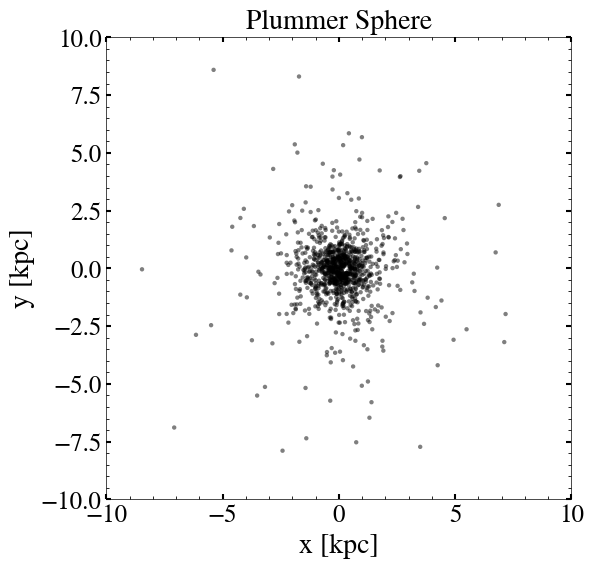

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(pos[:, 0], pos[:, 1], s=10, alpha=0.5)
plt.xlabel('x [kpc]', fontsize=20)
plt.ylabel('y [kpc]', fontsize=20)
plt.title('Plummer Sphere', fontsize=20)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

## Adding External Forces
🚧 *Still working on it...* 🚧
### Adding General External Forces
🚧 *Still working on it...* 🚧
### Adding Conservative Forces and Potentials
🚧 *Still working on it...* 🚧

